# SVR in depth analysis
2025-11-05, Alexander Minidis

2025-11-06 added Support vector with optimization, looks good. 

2025-11-16 functions moved to ML toos. Using IsolationForrest for the Outlier detection instead of LocalOutlier

2025-12-09 added drop constant features AFTER splitting; also: x-validation of different split sized

2026-02-18 - added logging function

### Water VEGA - including outliers. lower R2 but better MAE

In [1]:
from typing import Any
from pathlib import Path
import pandas as pd
import numpy as np

import sqlalchemy as sa
from sqlalchemy.orm import sessionmaker
from src.db_schema import *
from src.db_utils import get_selected_data
from src.rdkit_tools import MACCS_NAMES
from src.legacy.ml_tools import (
    drop_irrelevant_columns,
    scale_features,
    remove_variance_and_correlation,
    output_metrics,
    output_metrics_w_return,
)
from src.legacy.ml_tools import detect_and_remove_outliers
from src.legacy.log_utils import log_to_file, log_section
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVR
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 250)

In [2]:
# set directories and filenames, load database
working_dir = Path.cwd()
data_dir = working_dir / "processed_data"
database_file = data_dir / "t_half_vega_soil_water_sediment.db"
engine = sa.create_engine(f"sqlite:///{database_file}")
Session = sessionmaker(bind=engine)

In [3]:
# model settings - which data to use, target column and whether to use outlier removal
water_data = get_selected_data("water", Session)
data_to_use = drop_irrelevant_columns(water_data, to_drop=["None"])
target_column = "T_half_days"
use_outlier_removal = False


log_file = "5b2_water_vega_split_cross_val_svr_analysis.log"
if Path(log_file).exists():
    Path(log_file).unlink()  # remove existing log file to start fresh
log_to_file("WaterData, outlier removal: {}".format(use_outlier_removal), log_file, include_timestamp=True)

## Preprocessing

In [4]:
X, y = data_to_use.drop(columns=[target_column]), data_to_use[target_column]
print(f"Number of features: {X.shape[1]}, number of samples: {X.shape[0]}")
log_section("Preprocessing", log_file)
log_to_file(f"Number of samples: {X.shape[0]}, Number of features: {X.shape[1]}", log_file, include_timestamp=True)

Number of features: 375, number of samples: 223


In [5]:
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Any NaNs in X? {X.isna().any().any()}")
print(f"Any NaNs in y? {y.isna().any()}")
nan_mask = ~(X.isna().any(axis=1) | y.isna())
X = X[nan_mask]
y = y[nan_mask]
print(f"After dropping NaNs: {X.shape[0]} samples remain.")
print(f"After dropping NaNs: {X.shape[0]} samples remain.")
log_to_file(f"After dropping NaNs: {X.shape[0]} samples remain.", log_file, include_timestamp=True)

X shape: (223, 375), y shape: (223,)
Any NaNs in X? False
Any NaNs in y? False
After dropping NaNs: 223 samples remain.
After dropping NaNs: 223 samples remain.


In [6]:
# print rows with index X where NaNs
nan_indices = X[X.isna().any(axis=1)].index
if not nan_indices.empty:
    print("Rows with NaNs in target variable:")
    print(data_to_use.loc[nan_indices])
    log_to_file(f"Rows with NaNs in target variable:\n{data_to_use.loc[nan_indices]}", log_file, include_timestamp=True)

### 1. Outlier detection

In [7]:
if use_outlier_removal:
    X_clean, y_clean = detect_and_remove_outliers(X, y)
    print(f"Cleaned dataset: {X_clean.shape[0]} samples, {X_clean.shape[1]} features.")
    log_to_file(
        f"Outlier detection: {X_clean.shape[0]} samples, {X_clean.shape[1]} features.", log_file, include_timestamp=True
    )
    del X, y
    X = X_clean.copy()
    y = y_clean.copy()
else:
    print("Outlier removal not applied.")
    log_to_file("Outlier removal not applied.", log_file, include_timestamp=True)

Outlier removal not applied.


### 2. Scaling/normalization

In [8]:
X_scaled = scale_features(X)
log_to_file(f"After scaling: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features.", log_file, include_timestamp=True)
X_decorrelated = remove_variance_and_correlation(X_scaled, target_column)
log_to_file(
    f"After scaling and decorrelation: {X_decorrelated.shape[0]} samples, {X_decorrelated.shape[1]} features.",
    log_file,
    include_timestamp=True,
)

Number of features: 310, number of samples: 223
Number of features: 249, number of samples: 223


## Model

In [9]:
X = X_decorrelated.copy()
y = np.log10(y)
log_section("Model section", log_file)

In [10]:
# remove constant features, most likely none in complete X, but later after split (see the t_t_split function) there might be some
constant_features = [col for col in X.columns if X[col].nunique() == 1]
print("Constant features:", constant_features)
X = X.drop(columns=constant_features)
log_to_file(f"After removing constant features: {X.shape[0]} samples, {X.shape[1]} features.", log_file, include_timestamp=True)

Constant features: []


In [11]:
def t_t_split(X: pd.DataFrame, y: pd.Series, test_size: float = 0.2, random_state: int = 42) -> Any:
    """Split data into train and test sets, ensuring no constant features in either set."""

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    # Find constant features in train and test
    const_train = [col for col in X_train.columns if X_train[col].nunique() == 1]
    const_test = [col for col in X_test.columns if X_test[col].nunique() == 1]
    const_any = set(const_train) | set(const_test)
    # Remove from both sets
    X_train = X_train.drop(columns=const_any)
    X_test = X_test.drop(columns=const_any)
    return X_train, X_test, y_train, y_test

In [12]:
def svr_grid_search(X_train: pd.DataFrame, y_train: pd.Series) -> tuple[SVR, dict]:
    """Perform grid search to find the best SVR model.

    Parameters
    ----------
    X_train : pd.DataFrame
        _description_
    y_train : pd.Series
        _description_

    Returns
    -------
    SVR
        _description_
    """

    param_grid = {
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.01, 0.1, 0.2, 0.5],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto"],
    }

    svr = SVR()
    grid_search = GridSearchCV(svr, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print("Best parameters:", grid_search.best_params_)
    best_svr_estimate = grid_search.best_estimator_
    return best_svr_estimate, grid_search.best_params_

In [13]:
# Evaluate model performance across different test sizes
test_sizes = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
results = {}

for test_size in test_sizes:
    print(f"\nEvaluating for test size: {test_size}")
    X_train, X_test, y_train, y_test = t_t_split(X, y, test_size=test_size, random_state=42)
    svr, svr_params = svr_grid_search(X_train, y_train)
    svr.fit(X_train, y_train)
    y_pred_svr = svr.predict(X_test)
    # Inverse transform predictions and targets
    y_test_exp_svr = np.power(10, y_test)
    y_pred_exp_svr = np.power(10, y_pred_svr)
    # print('SVR metrics:')
    # output_metrics(y_test_exp_svr, y_pred_exp_svr)
    # print('\n')
    results[test_size] = {"y_test_exp_svr": y_test_exp_svr, "y_pred_exp_svr": y_pred_exp_svr, "params": svr_params}


Evaluating for test size: 0.15
Best parameters: {'C': 1, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}

Evaluating for test size: 0.2
Best parameters: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}

Evaluating for test size: 0.25
Best parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

Evaluating for test size: 0.3
Best parameters: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}

Evaluating for test size: 0.35
Best parameters: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}

Evaluating for test size: 0.4
Best parameters: {'C': 10, 'epsilon': 0.2, 'gamma': 'scale', 'kernel': 'rbf'}


In [14]:
# retrieve best result, then use the corresponding y_test_exp_svr and y_pred_exp_svr for further analysis
all_svr_metrics = {}
for test_size, y_values in results.items():
    y_test_exp_svr = y_values["y_test_exp_svr"]
    y_pred_exp_svr = y_values["y_pred_exp_svr"]
    metrics = output_metrics_w_return(y_test_exp_svr, y_pred_exp_svr)
    all_svr_metrics[test_size] = metrics

# Find the test size with the best R2
best_test_size = max(all_svr_metrics, key=lambda k: all_svr_metrics[k]["R2"])
best_metrics = all_svr_metrics[best_test_size]
best_r2 = best_metrics["R2"]
print(f"Best results at test size: {best_test_size}")
log_to_file(f"Best results at test size: {best_test_size}", log_file, include_timestamp=True)
params = results[best_test_size]["params"]
print(f"SVR parameters for best test size: {params}")
log_to_file(f"SVR parameters for best test size: {params}", log_file, include_timestamp=True)
# extract y_test_exp_svr and y_pred_exp_svr for best test size
y_test_exp_svr = results[best_test_size]["y_test_exp_svr"]
y_pred_exp_svr = results[best_test_size]["y_pred_exp_svr"]
output_metrics(y_test_exp_svr, y_pred_exp_svr)
log_to_file(
    f"SVR metrics for best test size ({best_test_size}):\n{output_metrics_w_return(y_test_exp_svr, y_pred_exp_svr)}",
    log_file,
    include_timestamp=True,
)

Best results at test size: 0.25
SVR parameters for best test size: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
R2: 0.900
MAE: 46.386
MSE: 19023.257
RMSE: 137.925
Explained Variance: 0.901


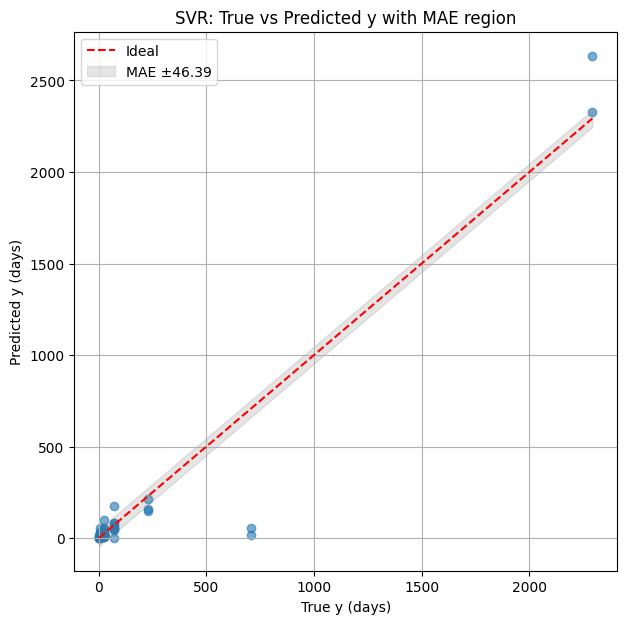

In [15]:
# SVR true vs predicted plot
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_exp_svr, y_pred_exp_svr)
plt.figure(figsize=(7, 7))
plt.scatter(y_test_exp_svr, y_pred_exp_svr, alpha=0.6)
plt.plot([min(y_test_exp_svr), max(y_test_exp_svr)], [min(y_test_exp_svr), max(y_test_exp_svr)], "r--", label="Ideal")
plt.fill_between(
    [min(y_test_exp_svr), max(y_test_exp_svr)],
    [min(y_test_exp_svr) + mae, max(y_test_exp_svr) + mae],
    [min(y_test_exp_svr) - mae, max(y_test_exp_svr) - mae],
    color="gray",
    alpha=0.2,
    label=f"MAE ±{mae:.2f}",
)
plt.xlabel("True y (days)")
plt.ylabel("Predicted y (days)")
plt.title("SVR: True vs Predicted y with MAE region")
plt.legend()
plt.grid(True)
plt.show()

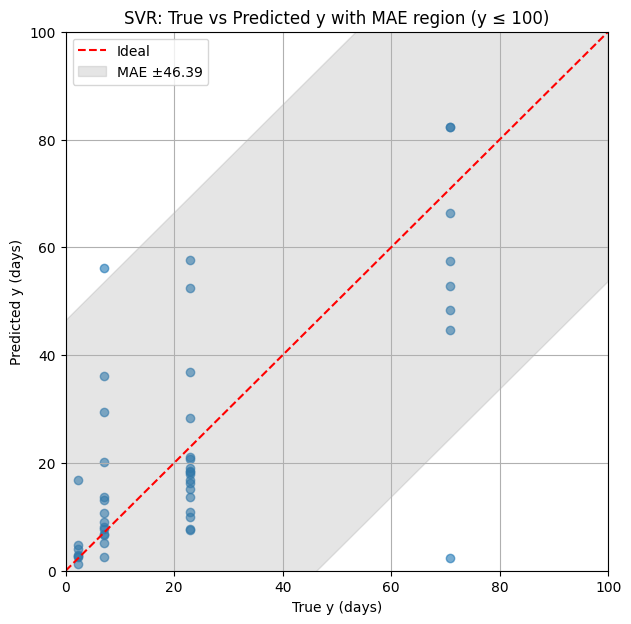

In [16]:
# Add shaded region for MAE to SVR true vs predicted plot, limited to x/y <= 100
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_exp_svr, y_pred_exp_svr)
plt.figure(figsize=(7, 7))
# Only plot points where both true and predicted are <= 100
mask = (y_test_exp_svr <= 100) & (y_pred_exp_svr <= 100)
plt.scatter(y_test_exp_svr[mask], y_pred_exp_svr[mask], alpha=0.6)
plt.plot([0, 100], [0, 100], "r--", label="Ideal")
plt.fill_between([0, 100], [mae, 100 + mae], [-mae, 100 - mae], color="gray", alpha=0.2, label=f"MAE ±{mae:.2f}")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("True y (days)")
plt.ylabel("Predicted y (days)")
plt.title("SVR: True vs Predicted y with MAE region (y ≤ 100)")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# retrieve best features by permutation importance for SVR
from sklearn.inspection import permutation_importance

result = permutation_importance(svr, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_mean_squared_error")

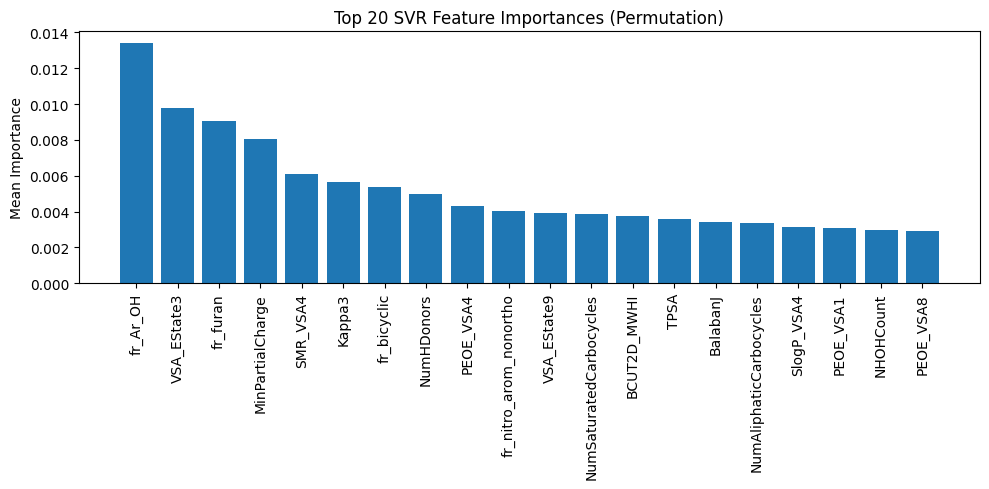

In [18]:
# plot top 20 features by permutation importance for SVR
importances = result.importances_mean
num_of_feats = 20
indices = np.argsort(importances)[::-1][:num_of_feats]
plt.figure(figsize=(10, 5))
plt.bar(range(num_of_feats), importances[indices])
plt.xticks(range(num_of_feats), X_test.columns[indices], rotation=90)
plt.title(f"Top {num_of_feats} SVR Feature Importances (Permutation)")
plt.ylabel("Mean Importance")
plt.tight_layout()
plt.show()

analysis of SVR

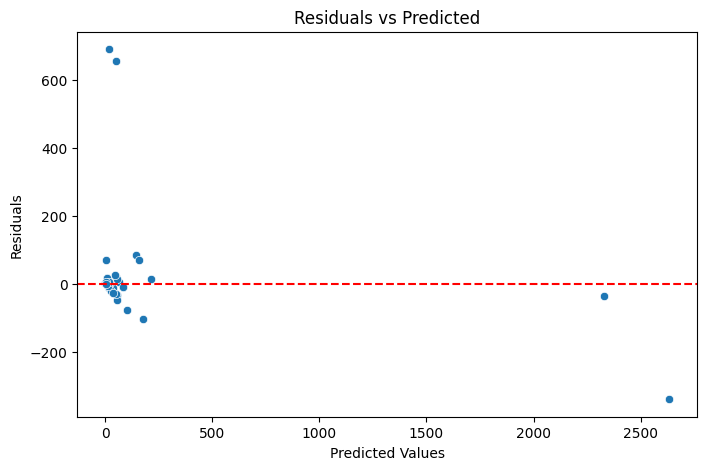

In [19]:
residuals = y_test_exp_svr - y_pred_exp_svr

# Scatter plot: Residuals vs Predicted
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_exp_svr, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

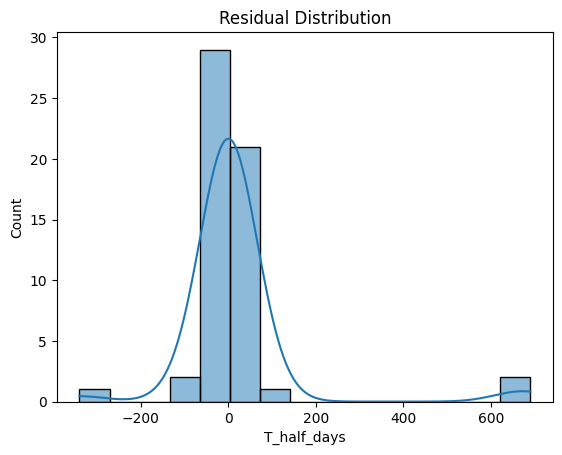

In [20]:
# Histogram of residuals
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

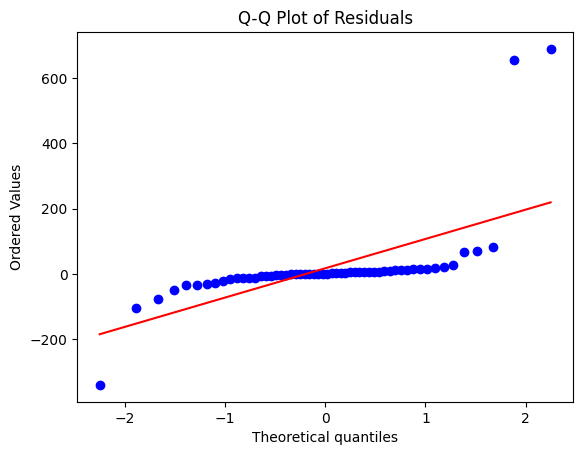

In [21]:
# Q-Q Plot using SciPy
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

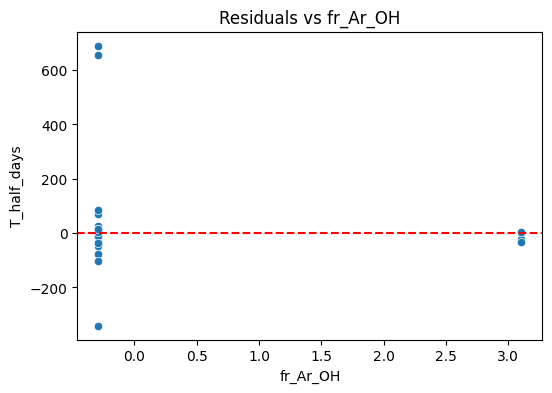

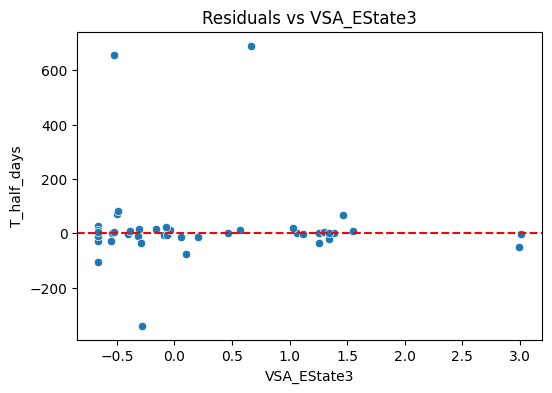

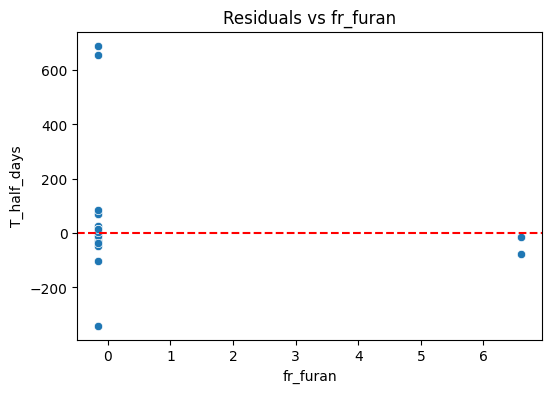

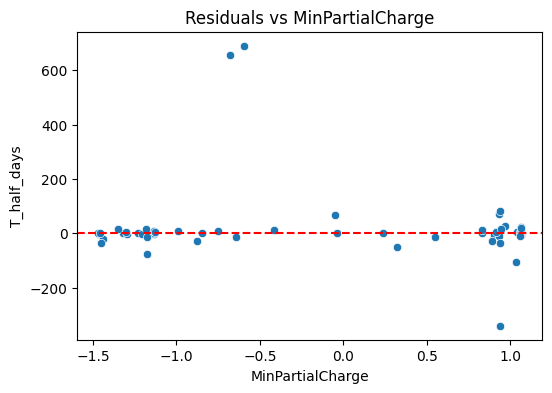

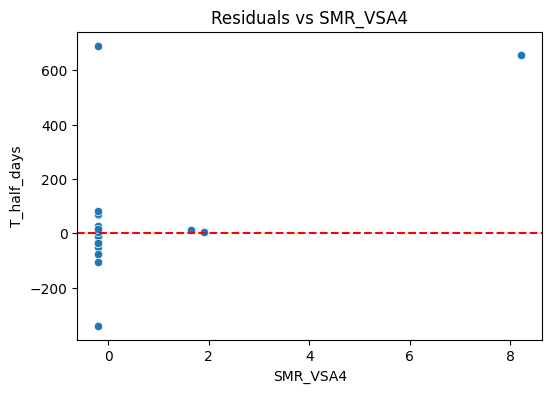

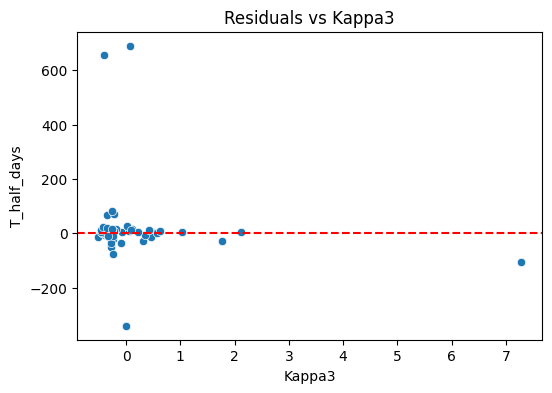

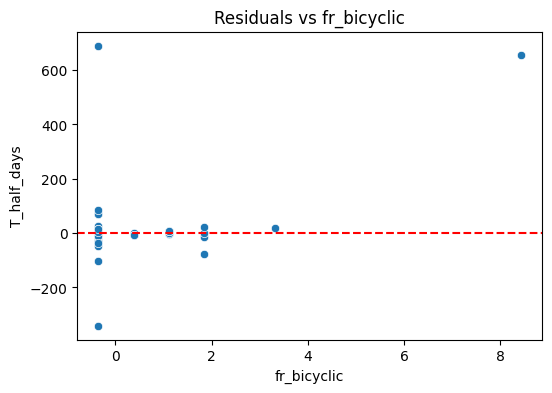

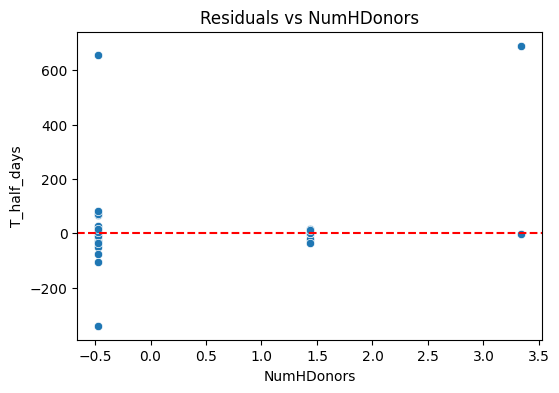

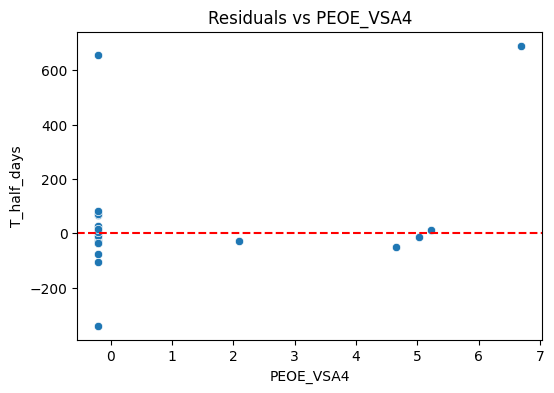

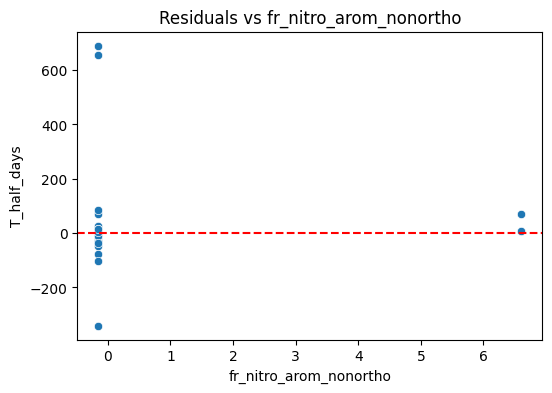

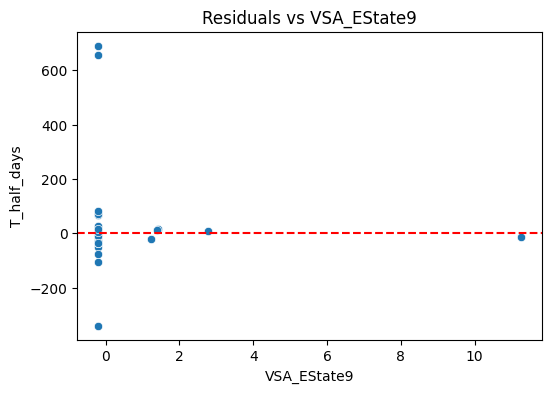

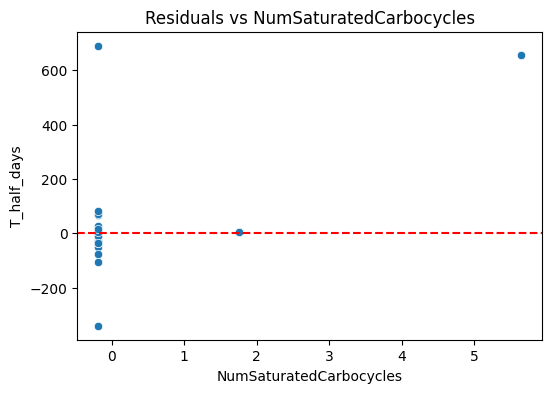

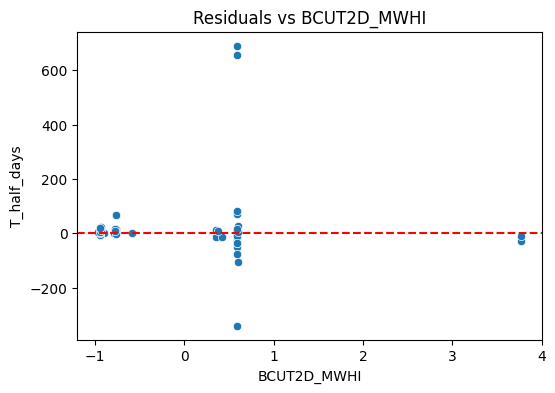

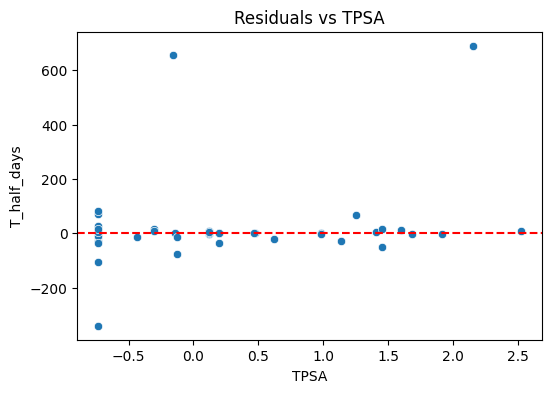

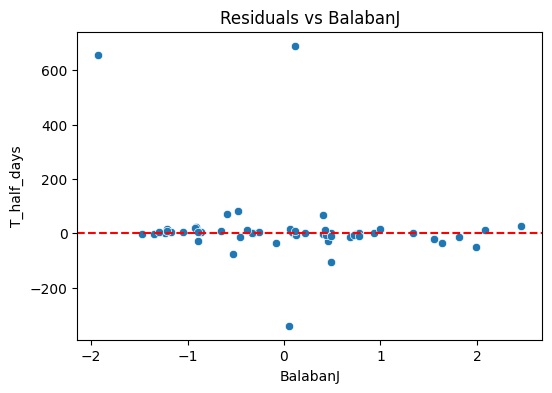

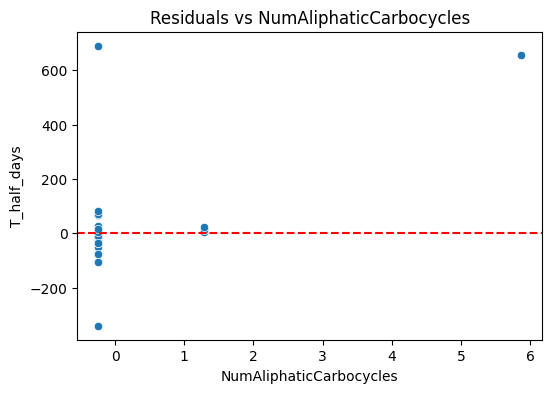

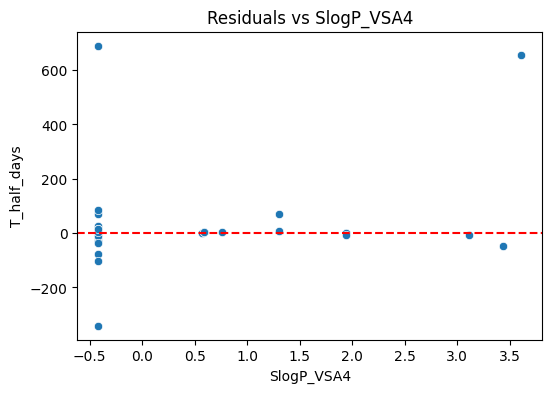

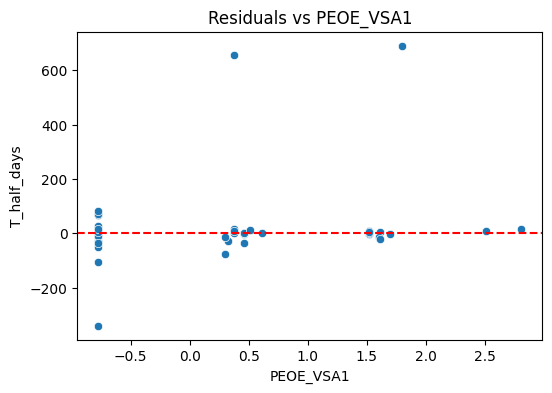

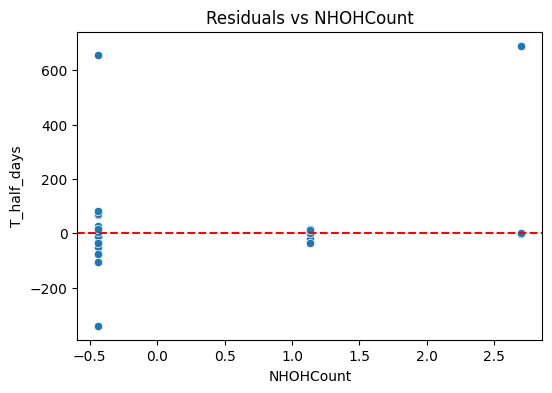

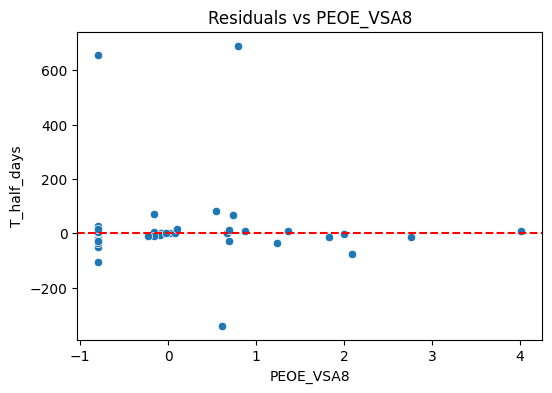

In [22]:
# Residuals vs Top Features by Permutation Importance
for col in X_test.columns[indices]:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_test[col], y=residuals)
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"Residuals vs {col}")
    plt.show()

In [23]:
# Or, print all residuals along with the feature value
for val, res in zip(X_test["fr_term_acetylene"], residuals):
    print(f"fr_term_acetylene: {val}, residual: {res}")

KeyError: 'fr_term_acetylene'